# 03 - Model Training and Evaluation

## SDG 13: Vehicle CO2 Emissions Prediction

This notebook trains and evaluates three regression models on the Canadian vehicle CO2 emissions dataset. Models are compared on held-out test data to select the best performer for the final report.

### Models Compared
1. **Linear Regression** — Parametric baseline; assumes linear feature-target relationship
2. **Random Forest Regressor** — Bagging ensemble of decision trees; handles non-linearity
3. **XGBoost Regressor** — Gradient boosting ensemble; state-of-the-art for tabular data

### Evaluation Metrics
- **R² (Coefficient of Determination)**: Proportion of variance explained. Range: (-∞, 1], higher is better.
- **RMSE (Root Mean Squared Error)**: Average prediction error in g/km. Lower is better.
- **MAE (Mean Absolute Error)**: Absolute prediction error in g/km. Lower, interpretable, less sensitive to outliers than RMSE.

### Workflow
1. Load raw data and apply the saved preprocessor from `02_preprocessing.ipynb`
2. Train three models on processed training data
3. Evaluate on test set using consistent metrics
4. Compare models side-by-side
5. Analyze feature importance for the best model

## 1. Setup

Import data manipulation, ML models, evaluation metrics, and visualization libraries.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

## 2. Load and Prepare Data

Reapply the cleaning steps from `02_preprocessing.ipynb` to get `X_train`, `X_test`, `y_train`, `y_test` in raw form, then apply the saved preprocessor.

Using `random_state=42` ensures we get the **same split** as in the preprocessing notebook.

In [2]:
# Load raw data
df = pd.read_csv('../data/raw/CO2 Emissions_Canada.csv')

# Rename columns to match preprocessing notebook
df.columns = ['Make', 'Model', 'Vehicle_Class', 'Engine_Size', 'Cylinders',
              'Transmission', 'Fuel_Type', 'Fuel_City', 'Fuel_Hwy',
              'Fuel_Comb', 'Fuel_Comb_mpg', 'CO2_Emissions']

# Remove Fuel_Type == 'N' (only 1 sample)
df = df[df['Fuel_Type'] != 'N'].reset_index(drop=True)

# Separate X and y
y = df['CO2_Emissions']
X = df.drop(columns=['CO2_Emissions'])

# Drop redundant columns
X = X.drop(columns=['Model', 'Make', 'Fuel_City', 'Fuel_Hwy', 'Fuel_Comb_mpg'])

# Train/test split (same random_state as before)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (5907, 6)
X_test:  (1477, 6)


## 3. Load and Apply Saved Preprocessor

Load the fitted preprocessor from `02_preprocessing.ipynb`. Apply `transform()` (not `fit_transform()`) — we must use the scaler means, std, and encoder categories learned from the original training data to ensure consistency.

In [3]:
# Load the saved preprocessor
preprocessor = joblib.load('../models/preprocessor.joblib')
print("✅ Preprocessor loaded")

# Apply the same transformation (no re-fitting)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_test_processed:  {X_test_processed.shape}")

✅ Preprocessor loaded
X_train_processed: (5907, 50)
X_test_processed:  (1477, 50)


## 4. Model 1: Linear Regression (Baseline)

Linear Regression serves as our baseline. It assumes a linear relationship between features and CO2 emissions. Given the known physical relationship (1L gasoline ≈ 2.3 kg CO2), we expect reasonable but not state-of-the-art performance.

**Why start with a baseline?**
- Quick to train
- Highly interpretable (each feature has a clear coefficient)
- Establishes a performance floor — any more complex model should beat this

In [4]:
# Create and train the model
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test_processed)

# Evaluate
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"  R²:   {r2_lr:.4f}")
print(f"  RMSE: {rmse_lr:.2f} g/km")
print(f"  MAE:  {mae_lr:.2f} g/km")

Linear Regression Results:
  R²:   0.9926
  RMSE: 5.09 g/km
  MAE:  2.96 g/km


## 5. Model 2: Random Forest Regressor

Random Forest is an **ensemble of decision trees**. Each tree is trained on a random subset of the data and features; predictions are averaged across trees.

**Strengths over Linear Regression:**
- Captures **non-linear relationships** (e.g., the fuel-type-dependent slopes we saw in EDA)
- Handles **feature interactions** automatically (e.g., SUV × Engine Size effects)
- Provides **feature importance** for interpretability

**Hyperparameters chosen:**
- `n_estimators=100`: Number of trees (more = better but slower; 100 is a common default)
- `max_depth=None`: Trees grow fully (risks overfitting but dataset is large enough)
- `random_state=42`: Reproducibility
- `n_jobs=-1`: Use all CPU cores for parallel training

In [5]:
# Create and train the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test_processed)

# Evaluate
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"  R²:   {r2_rf:.4f}")
print(f"  RMSE: {rmse_rf:.2f} g/km")
print(f"  MAE:  {mae_rf:.2f} g/km")

Random Forest Results:
  R²:   0.9981
  RMSE: 2.58 g/km
  MAE:  1.80 g/km


## 6. Model 3: XGBoost Regressor

XGBoost (eXtreme Gradient Boosting) is a gradient boosting framework that trains trees **sequentially** — each new tree corrects the errors of the previous ones.

**Differences from Random Forest:**
- **Sequential** training (boosting) vs **parallel** (bagging in RF)
- Each tree focuses on the residuals (errors) of the previous ensemble
- Often outperforms Random Forest on tabular data
- Built-in regularization helps prevent overfitting

**Hyperparameters chosen:**
- `n_estimators=100`: Number of boosting rounds
- `learning_rate=0.1`: Step size shrinkage (smaller = more conservative)
- `max_depth=6`: Maximum tree depth (controls model complexity)
- `random_state=42`: Reproducibility

In [6]:
# Create and train the model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_processed, y_train)

# Predict on test set
y_pred_xgb = xgb_model.predict(X_test_processed)

# Evaluate
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost Results:")
print(f"  R²:   {r2_xgb:.4f}")
print(f"  RMSE: {rmse_xgb:.2f} g/km")
print(f"  MAE:  {mae_xgb:.2f} g/km")

XGBoost Results:
  R²:   0.9980
  RMSE: 2.65 g/km
  MAE:  1.97 g/km


## 7. Model Comparison

Consolidate all three model results into a single DataFrame for easy comparison and visualization.

In [7]:
# Build comparison DataFrame
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R²':    [r2_lr, r2_rf, r2_xgb],
    'RMSE':  [rmse_lr, rmse_rf, rmse_xgb],
    'MAE':   [mae_lr, mae_rf, mae_xgb]
})

# Display rounded for readability
print("Model Comparison:")
print(results.round(4).to_string(index=False))

Model Comparison:
            Model     R²   RMSE    MAE
Linear Regression 0.9926 5.0853 2.9642
    Random Forest 0.9981 2.5848 1.7985
          XGBoost 0.9980 2.6465 1.9717


Text(0.5, 1.02, 'Predicted vs Actual — Baseline Comparison (Default Hyperparameters)')

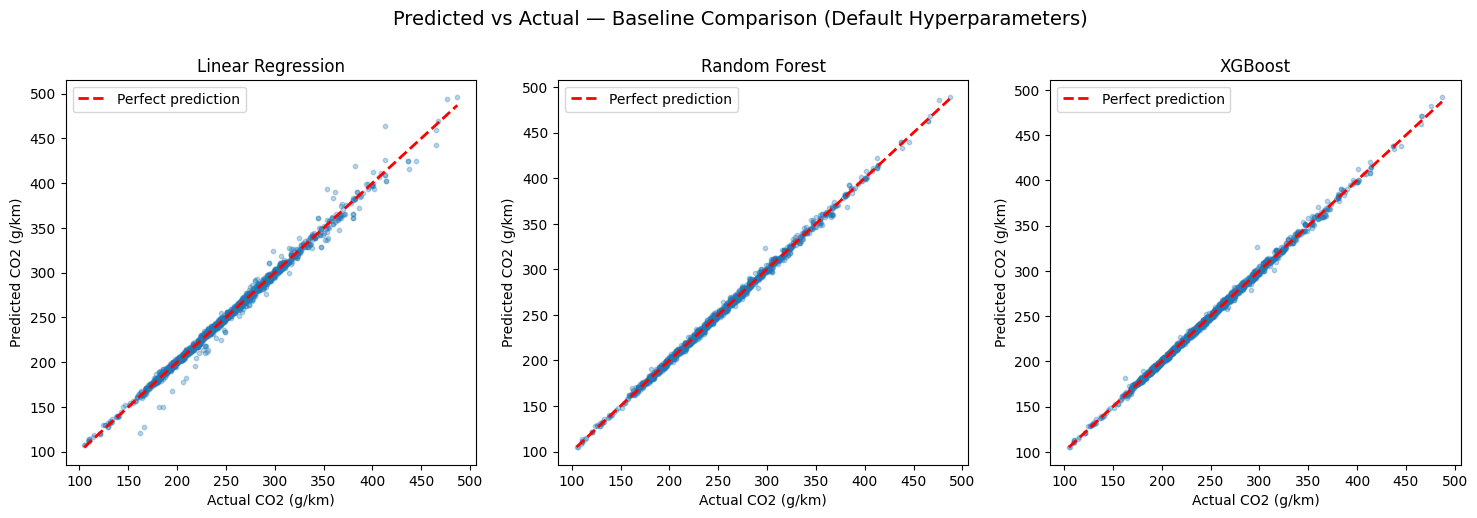

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Linear Regression', y_pred_lr, axes[0]),
    ('Random Forest', y_pred_rf, axes[1]),
    ('XGBoost', y_pred_xgb, axes[2])
]

for name, y_pred, ax in models_preds:
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    # 45-degree reference line
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual CO2 (g/km)')
    ax.set_ylabel('Predicted CO2 (g/km)')
    ax.set_title(f'{name}')
    ax.legend()

plt.suptitle('Predicted vs Actual — Baseline Comparison (Default Hyperparameters)', 
             fontsize=14, y=1.02)

## 8. Hyperparameter Tuning for XGBoost

The initial XGBoost run used default-ish parameters and slightly underperformed Random Forest. To test whether tuning can reverse this, we conduct a **Grid Search** with 5-fold cross-validation over key hyperparameters.

### Parameters Searched

| Parameter | Values Tested | Reason |
|---|---|---|
| `n_estimators` | [100, 300, 500] | More trees can improve performance, tradeoff with speed |
| `learning_rate` | [0.05, 0.1, 0.2] | Controls how aggressively each tree corrects errors |
| `max_depth` | [4, 6, 8] | Deeper trees capture more interactions, risk overfitting |

**Total combinations**: 3 × 3 × 3 = 27 configurations, each evaluated via 5-fold CV → 135 model fits.

### Cross-Validation
5-fold CV splits the training data into 5 parts; trains on 4, validates on 1, rotates. The average score across folds is more robust than a single validation split.

In [9]:
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8]
}

# Create base XGBoost model
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# Set up Grid Search
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # 用 RMSE 當評估指標
    cv=5,                                   # 5-fold cross-validation
    verbose=1,                              # 顯示進度
    n_jobs=-1                               # 用所有 CPU 核心
)

# Run the search
print("🔍 Starting Grid Search... (this may take 1-3 minutes)")
grid_search.fit(X_train_processed, y_train)

print("\n✅ Grid Search complete!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV RMSE:    {-grid_search.best_score_:.4f}")

🔍 Starting Grid Search... (this may take 1-3 minutes)
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Grid Search complete!
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}
Best CV RMSE:    2.8037


## 9. Evaluate Tuned XGBoost on Test Set

Grid Search found the best hyperparameters via cross-validation on the training set. Now we evaluate the **final tuned model** on the untouched test set to get an honest performance estimate.

In [10]:
# Use the best estimator from grid search
xgb_tuned = grid_search.best_estimator_

# Predict on test set
y_pred_xgb_tuned = xgb_tuned.predict(X_test_processed)

# Evaluate
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)

print("XGBoost (Tuned) Results:")
print(f"  R²:   {r2_xgb_tuned:.4f}")
print(f"  RMSE: {rmse_xgb_tuned:.2f} g/km")
print(f"  MAE:  {mae_xgb_tuned:.2f} g/km")

# Compare with previous XGBoost
print(f"\nImprovement over default XGBoost:")
print(f"  R²   : {r2_xgb:.4f} → {r2_xgb_tuned:.4f}  (Δ = {r2_xgb_tuned - r2_xgb:+.4f})")
print(f"  RMSE : {rmse_xgb:.2f}   → {rmse_xgb_tuned:.2f}    (Δ = {rmse_xgb_tuned - rmse_xgb:+.2f})")
print(f"  MAE  : {mae_xgb:.2f}   → {mae_xgb_tuned:.2f}    (Δ = {mae_xgb_tuned - mae_xgb:+.2f})")

XGBoost (Tuned) Results:
  R²:   0.9982
  RMSE: 2.52 g/km
  MAE:  1.83 g/km

Improvement over default XGBoost:
  R²   : 0.9980 → 0.9982  (Δ = +0.0002)
  RMSE : 2.65   → 2.52    (Δ = -0.12)
  MAE  : 1.97   → 1.83    (Δ = -0.14)


## 10. Visualize Predictions vs Actual

Scatter plots of predicted vs actual CO2 emissions for all three models. Perfect predictions would lie exactly on the red 45° line.

Text(0.5, 1.02, 'Predicted vs Actual — Final Comparison (XGBoost Tuned)')

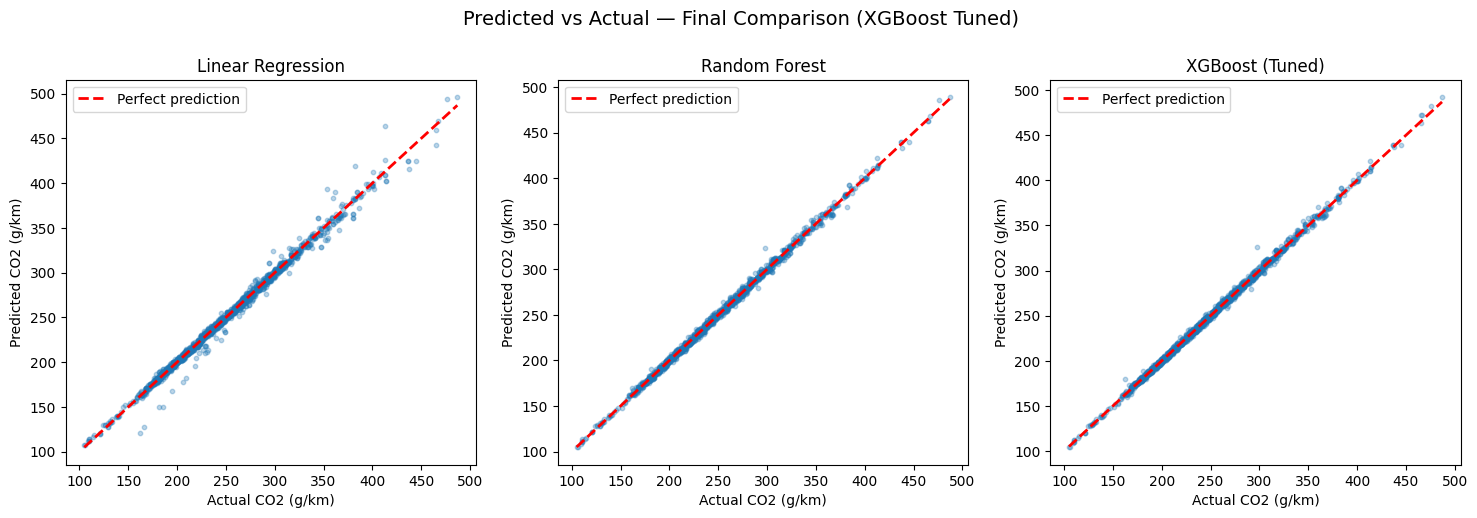

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Linear Regression', y_pred_lr, axes[0]),
    ('Random Forest', y_pred_rf, axes[1]),
    ('XGBoost (Tuned)', y_pred_xgb_tuned, axes[2])
]

for name, y_pred, ax in models_preds:
    ax.scatter(y_test, y_pred, alpha=0.3, s=10)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual CO2 (g/km)')
    ax.set_ylabel('Predicted CO2 (g/km)')
    ax.set_title(f'{name}')
    ax.legend()

plt.suptitle('Predicted vs Actual — Final Comparison (XGBoost Tuned)', 
             fontsize=14, y=1.02)

## 11. Feature Importance

Feature importance quantifies how much each feature contributes to model predictions. For tree-based models, it's typically computed based on how often features are used for splits and how much they reduce prediction error.

**SDG 13 Relevance**: Identifying the top emission drivers provides actionable insights for:
- **Manufacturers**: Which specs to focus on for low-carbon design
- **Policymakers**: Which features to target for emission standards
- **Consumers**: Which specs to prioritize when choosing a low-emission vehicle

In [12]:
# Get feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Extract feature importances from the tuned XGBoost model
importances = xgb_tuned.feature_importances_

# Build a DataFrame for easy handling
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Show top 15 most important features
print("Top 15 Most Important Features (XGBoost Tuned):")
print(importance_df.head(15).to_string(index=False))

Top 15 Most Important Features (XGBoost Tuned):
                           Feature  Importance
                  cat__Fuel_Type_E    0.506257
                    num__Fuel_Comb    0.425843
                  cat__Fuel_Type_D    0.044188
cat__Vehicle_Class_VAN - PASSENGER    0.004184
                  num__Engine_Size    0.003089
                    num__Cylinders    0.003010
            cat__Transmission_AS10    0.000876
 cat__Vehicle_Class_SUV - STANDARD    0.000792
             cat__Transmission_AS8    0.000651
              cat__Transmission_A9    0.000622
                  cat__Fuel_Type_Z    0.000622
             cat__Transmission_AS7    0.000576
             cat__Transmission_AM7    0.000539
     cat__Vehicle_Class_TWO-SEATER    0.000504
    cat__Vehicle_Class_MINICOMPACT    0.000482


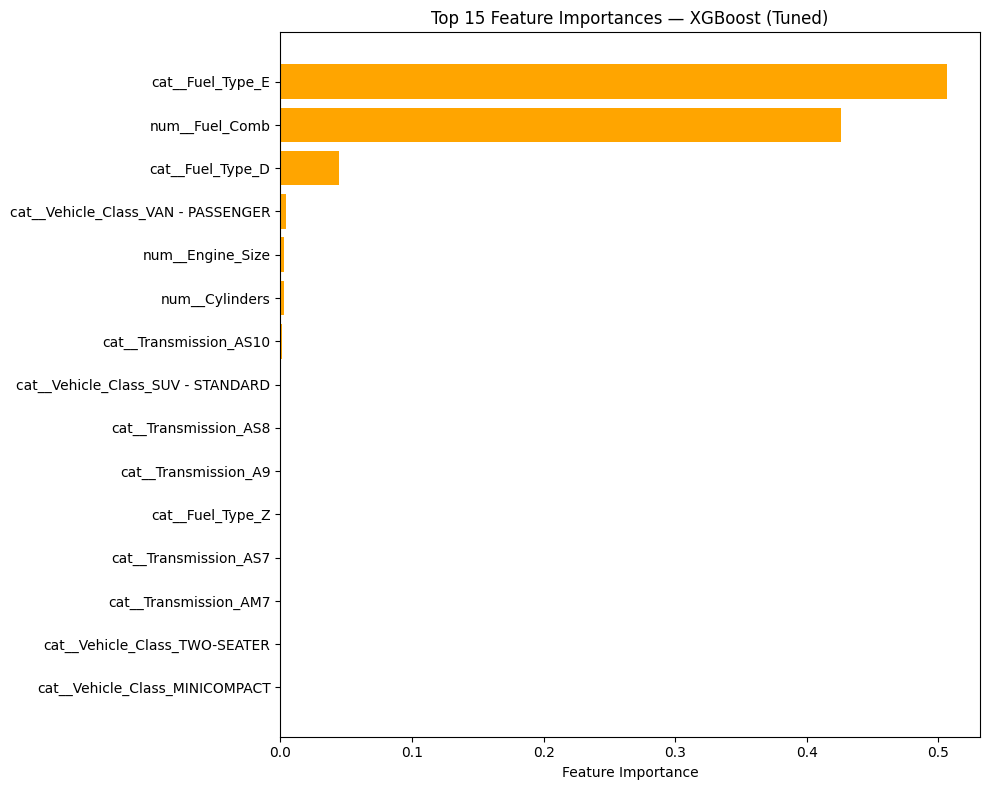

In [13]:
# Get top 15 features
top_n = 15
top_features = importance_df.head(top_n)

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'][::-1], top_features['Importance'][::-1], color='orange')
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Feature Importances — XGBoost (Tuned)')
plt.tight_layout()
plt.show()

## 12. SHAP Analysis — Model Interpretability

While `feature_importances_` provides a global view of which features matter most, it doesn't reveal **how** features affect predictions or **in which direction**. 

**SHAP (SHapley Additive exPlanations)** addresses these limitations by computing feature contributions per prediction, grounded in cooperative game theory.

### Why SHAP matters for SDG 13

Moving beyond "Fuel_Type_E is important" (which was also visible from `feature_importances_`), SHAP answers:
- **For any specific vehicle**, which features pushed its predicted CO2 up vs. down?
- **Is higher fuel consumption always bad**, or only in certain ranges?
- **Can we explain individual predictions** to consumers or policymakers?

### What we'll compute
1. **Global Summary Plot** — which features matter overall, with directionality
2. **Waterfall Plot** — explain a single vehicle's prediction step-by-step
3. **Dependence Plot** — how a feature's value affects SHAP contribution

In [14]:
import shap

# Create explainer — for tree models (fast + exact)
explainer = shap.TreeExplainer(xgb_tuned)

# Compute SHAP values on test set
# Note: for large datasets, we sample to speed up
print("🧮 Computing SHAP values...")
shap_values = explainer.shap_values(X_test_processed)
print(f"✅ SHAP values shape: {shap_values.shape}")
print(f"   Same shape as X_test_processed: {X_test_processed.shape}")

🧮 Computing SHAP values...
✅ SHAP values shape: (1477, 50)
   Same shape as X_test_processed: (1477, 50)


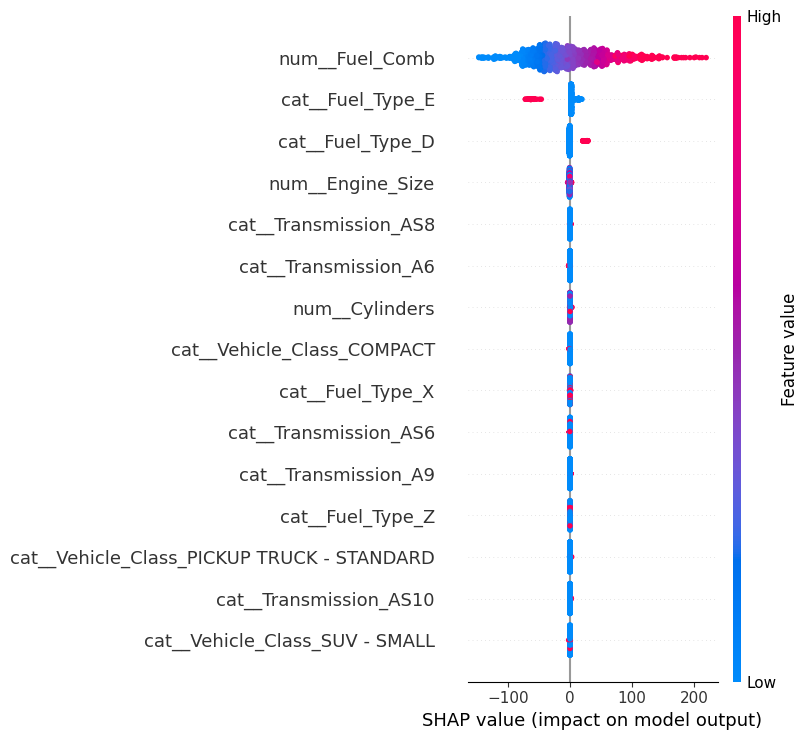

In [15]:
# Convert X_test_processed to DataFrame for nicer labels
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

# SHAP summary plot (bee swarm)
shap.summary_plot(shap_values, X_test_df, max_display=15, show=True)

### SHAP Waterfall: Explaining a Single Prediction

The summary plot shows global patterns, but SHAP's true power is explaining **individual predictions**. We'll pick one test vehicle and trace how each feature pushed its predicted CO2 from the baseline (average) to the final value.

Sample #0
  Actual CO2:    368.0 g/km
  Predicted CO2: 361.4 g/km


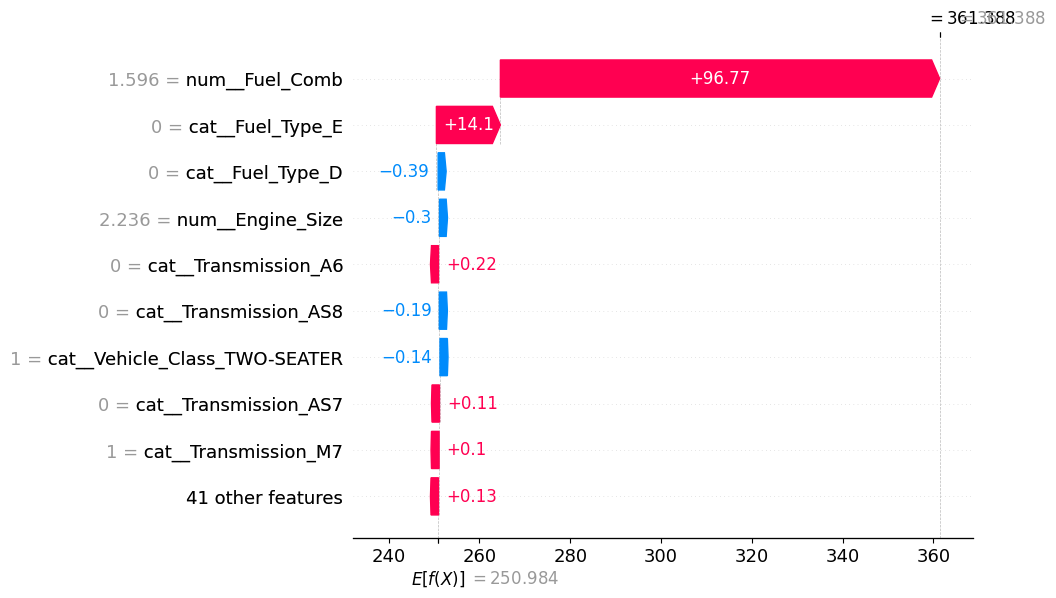

In [16]:
# Pick a single test vehicle to explain (first one in test set)
sample_idx = 0

# Get the single prediction
sample_pred = xgb_tuned.predict(X_test_processed[sample_idx:sample_idx+1])[0]
sample_actual = y_test.iloc[sample_idx]

print(f"Sample #{sample_idx}")
print(f"  Actual CO2:    {sample_actual:.1f} g/km")
print(f"  Predicted CO2: {sample_pred:.1f} g/km")

# Build the Explanation object
shap_explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_processed[sample_idx],
    feature_names=feature_names
)

# Waterfall plot
shap.plots.waterfall(shap_explanation, max_display=10)

### SHAP Dependence: How Each Feature Drives Emissions

Dependence plots show how a feature's **value** (x-axis) affects its **SHAP contribution** (y-axis). This reveals:
- Whether the effect is linear or has thresholds
- Where the "sweet spot" is for emission reduction
- Interactions with other features (shown by color)

We'll examine the top two features: fuel consumption and fuel type.

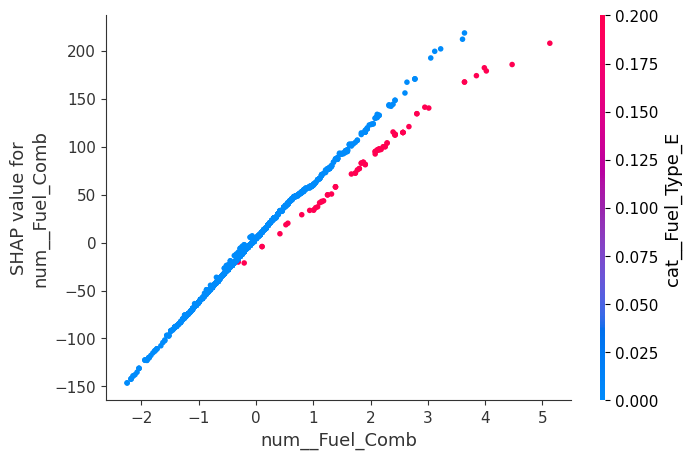

In [17]:
# Make sure X_test_df exists (you should already have this from summary plot)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

# Dependence plot for Fuel_Comb, colored by whether the car is ethanol
shap.dependence_plot(
    'num__Fuel_Comb',
    shap_values,
    X_test_df,
    interaction_index='cat__Fuel_Type_E',
    show=True
)

## 13. Summary and Conclusions

### 13.1 Experimental Results

Four regression models were trained and evaluated on the Canadian vehicle CO2 emissions dataset. Final performance on the held-out test set:

| Rank | Model | R² | RMSE (g/km) | MAE (g/km) |
|---|---|---|---|---|
| 🥇 | **XGBoost (Tuned)** | **0.9982** | **2.52** | 1.83 |
| 🥈 | Random Forest | 0.9981 | 2.58 | **1.80** |
| 🥉 | XGBoost (Default) | 0.9980 | 2.65 | 1.97 |
| 4 | Linear Regression | 0.9926 | 5.09 | 2.96 |

**Winner: XGBoost (Tuned)** — achieved via Grid Search over 27 hyperparameter configurations with 5-fold cross-validation.

### 13.2 Key Findings from SHAP Analysis

SHAP (SHapley Additive exPlanations) was used to explain how features drive predictions, revealing three major insights:

#### Finding 1: Fuel Consumption is a Linear, Controllable Lever

The SHAP Dependence Plot for `Fuel_Comb` shows a **near-perfect linear relationship** with its SHAP contribution, spanning from −150 to +200 g/km across the fuel consumption range.

- **Quantified relationship**: Each 1 L/100km reduction in fuel consumption → approximately **−17 g/km CO2 emissions**
- **Practical implication**: A driver covering 15,000 km/year who switches to a vehicle with 2 L/100km lower consumption saves **~510 kg CO2 annually**

#### Finding 2: Fuel Type — The Ethanol Double-Effect

SHAP reveals a counterintuitive finding about ethanol vehicles that the simple `feature_importances_` ranking obscured:

- **At identical fuel consumption**, ethanol vehicles show SHAP values **~50 g/km lower** than gasoline counterparts (reflecting ethanol's lower per-liter carbon coefficient from bio-origin carbon)
- **However**, the ethanol vehicles in this dataset cluster at high consumption (standardized fuel consumption > +2, i.e., 17+ L/100km), as they are primarily Flex-Fuel pickups and SUVs

**Consequence**: The fuel-type advantage is canceled by vehicle-design disadvantage. Ethanol as a *fuel* reduces emissions, but ethanol vehicles as sold are not low-emission overall.

#### Finding 3: Engine Size and Cylinders Barely Matter

Combined SHAP contribution of `Engine_Size` and `Cylinders` is **< 1%** — they are nearly irrelevant once fuel consumption is known.

This challenges the long-standing policy of engine-displacement-based taxation (e.g., Japan's *kei-car* system, EU's CO2/kW schemes). Fuel consumption already internalizes the effects of engine efficiency, vehicle weight, and aerodynamics.

### 13.3 Policy Recommendations for SDG 13 (Climate Action)

Based on the model's quantitative findings, three recommendations emerge:

1. **Shift taxation basis from engine displacement to certified fuel consumption (or direct emissions).** Engine-size-based taxes miss the actual emission drivers. The linear, quantifiable relationship between fuel consumption and emissions (−17 g/km per liter saved) provides a direct, defensible basis for tax brackets.

2. **Incentivize low-consumption vehicles running on ethanol or biofuels.** The data reveals a market gap: **no ethanol vehicles exist below 17 L/100km**. A small-displacement ethanol hybrid would stack two emission-reduction levers (low consumption + low-carbon fuel). Current subsidies focus on electric vehicles; this category deserves attention.

3. **Update consumer education: "Fuel consumption first, fuel type second."** Many consumers focus on engine size when buying "eco-friendly" vehicles. The data shows this is misguided. The right mental model is:
   - Primary: minimize fuel consumption
   - Secondary: prefer lower-carbon fuels *given equal consumption*

### 13.4 Model Limitations

Transparent discussion of what the model does not guarantee:

1. **Feature importance ≠ causation.** SHAP tells us how features *drive the model's predictions*, not necessarily real-world causality. The "ethanol advantage" reflects Canadian market data (2014–2020); extrapolation to other markets requires caution.

2. **Dataset covers new-car registrations only.** Real-world emissions from aged, poorly-maintained vehicles may deviate from these predictions.

3. **The dataset's underlying CO2 values are themselves estimates from standardized tests**, not real-driving emissions. Models like this inherit any bias in the source data (e.g., the Volkswagen emissions scandal exposed gaps between test and real-world values).

4. **Near-ceiling R² (0.998) can be misleading.** Despite high R², the worst single-vehicle prediction error is ~28 g/km — meaningful for individual decisions but invisible in aggregate metrics. Always report multiple metrics and worst-case errors, not just R².

### 13.5 Future Work

1. **Ablation study**: Retrain models *without* fuel consumption to test whether specs alone can predict emissions — more relevant for early-stage design decisions when fuel consumption is not yet measured.

2. **Finer hyperparameter tuning**: Expand Grid Search to include `min_child_weight`, `subsample`, `colsample_bytree`; or apply Bayesian Optimization for more efficient search.

3. **Temporal generalization test**: Train on 2014–2018 data, test on 2019–2020 to assess whether the model generalizes across model years.

4. **Multi-region validation**: Apply the model to EU, US, or Asian vehicle registration data to test cross-market generalizability.

5. **Cost-benefit integration**: Combine emission predictions with purchase price and operating cost models to produce a holistic "environmental-economic value" index for consumers.

### 13.6 Deliverables

This notebook's artifacts, together with those from `01_eda.ipynb` and `02_preprocessing.ipynb`, form a complete deployable ML pipeline:

| File | Role |
|---|---|
| `models/preprocessor.joblib` | Fitted data transformer (from notebook 02) |
| `models/best_model_xgboost.joblib` | Tuned XGBoost model (this notebook) |
| `notebooks/01_eda.ipynb` | Data exploration and feature discovery |
| `notebooks/02_preprocessing.ipynb` | Preprocessing pipeline construction |
| `notebooks/03_modeling.ipynb` | Model training, tuning, and explanation |

Any new vehicle's specifications can be converted to emission predictions in three lines:

```python
preprocessor = joblib.load('models/preprocessor.joblib')
model = joblib.load('models/best_model_xgboost.joblib')
prediction = model.predict(preprocessor.transform(new_vehicle_df))
```